# SmartBank Customer Churn Model
### Lloyds Banking Group 'Customer Retention Enhancement through Predictive Analytics' Initiative
### Analysis by: Breanna Williams
#### November 28, 2025
---
---
---

### Necessary Libraries & Packages

In [1]:
# Base imports
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Plotting imports
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette('Set1')

# Modeling imports
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.preprocessing import PolynomialFeatures


# Metrics imports
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score, PrecisionRecallDisplay, precision_recall_curve, ConfusionMatrixDisplay, confusion_matrix

# Explainability imports
import shap

# Serialization imports
import pickle

---
### Loading and Checking Cleaned Dataset

In [2]:
data = pd.read_csv('../data/clean_customer_churn_data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   CustomerID                      1000 non-null   int64  
 1   ChurnStatus                     1000 non-null   int64  
 2   Age                             1000 non-null   int64  
 3   Gender                          1000 non-null   object 
 4   MaritalStatus                   1000 non-null   object 
 5   IncomeLevel                     1000 non-null   object 
 6   NumInteractions                 668 non-null    float64
 7   DaysSinceLastInteraction        668 non-null    float64
 8   ResolutionRate                  668 non-null    float64
 9   PctInteractionType_Feedback     668 non-null    float64
 10  PctInteractionType_Inquiry      668 non-null    float64
 11  LoginFrequency                  1000 non-null   int64  
 12  DaysSinceLastLogin              100

In [3]:
# Converting ordered object columns to categorical
data['IncomeLevel'] = pd.Categorical(data['IncomeLevel'], categories=['Low', 'Medium', 'High'], ordered=True)

In [4]:
# Converting object columns to categorical
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].astype('category')

---
### Split the Data

In [5]:
CustomerID = data['CustomerID'].copy()      # Save CustomerID for deployment
X = data.drop(['ChurnStatus', 'CustomerID'], axis=1)
y = data['ChurnStatus']


In [6]:
# Split the data using stratified sampling to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
# Checking sizes of split data
for i in [X_train, X_test, y_train, y_test]:
    print(round(len(i)/len(data), 2))

0.8
0.2
0.8
0.2


---
### Preprocess the Data

In [8]:
# Seperating features by data type
numeric_columns = X_train.select_dtypes(include='number').columns.tolist()
nominal_columns = X_train.select_dtypes(include='category').columns.tolist()
nominal_columns.remove('IncomeLevel')
ordinal_columns = ['IncomeLevel']

In [9]:
# Create preprocessing pipelines for different feature types
numeric_pipeline = make_pipeline(SimpleImputer(strategy='median', add_indicator=True),  # Impute missing values and add indicator for missingness
                                PowerTransformer(method='yeo-johnson'),        # Handles multi-directional skew
                                StandardScaler())                              # Normalizes features and handles outliers
                                                                    
nominal_pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'),
                                OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 

ordinal_pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'),
                                OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))

In [10]:
# Create the ColumnTransformer to apply the pipelines
transformer = ColumnTransformer([
                        ('num', numeric_pipeline, numeric_columns),
                        ('nom', nominal_pipeline, nominal_columns),
                        ('ord', ordinal_pipeline, ordinal_columns)
                        ])

In [11]:
# Set transformer to output a pandas DataFrame with non-verbose feature names
transformer.set_output(transform='pandas')
transformer.set_params(verbose_feature_names_out=False)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(add_indicator=True,
                                                                strategy='median')),
                                                 ('powertransformer',
                                                  PowerTransformer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Age', 'NumInteractions',
                                  'DaysSinceLastInteraction', 'ResolutionRate',
                                  'PctInteractionType_Feedback',
                                  'PctInteractionType_Inquiry',
                                  'LoginFrequency', 'D...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Gender', 'MaritalStatus']),
                                ('ord',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['IncomeLevel'])],
                  verbose_feature_names_out=False)

---
### Defining Helper Functions for Model Evaluation and Visualization


In [12]:
def train_eval(model, X_train, y_train):
    '''
    Description: Fits model on full training data, runs CV on training data,
    and returns (results_df, fitted_model).

    Parameters: 
        model: The machine learning model to be trained and evaluated.
        X_train: pandas DataFrame. Features for training.
        y_train: pandas Series or array-like. Target labels.

    Returns:
        results_df: pandas DataFrame.
        fitted_model: The model fitted on the full training data.
    '''
    # Fit on full, transformed,training set
    fitted_model = model.fit(X_train, y_train)

    # Make train-set predictions and probabilities
    y_pred_train  = fitted_model.predict(X_train)
    y_proba_train = fitted_model.predict_proba(X_train)[:, 1]

    # Calculate train AUC
    train_auc = roc_auc_score(y_train, y_proba_train)

    if hasattr(fitted_model, 'named_steps') and 'model' in fitted_model.named_steps:
        model_name = fitted_model.named_steps['model'].__class__.__name__
    else:
        model_name = fitted_model.__class__.__name__

    print('\n=== Classification Report (Train) ===')
    print(classification_report(y_train, y_pred_train))

    results = {
        'Dataset': 'Train',
        'Model': model_name,
        'ROC-AUC': train_auc.round(2)
    }

    return pd.DataFrame([results]), fitted_model


In [13]:
test_results = []
def test_eval(fitted_model, X_test, y_test):
    '''
    Description: Uses an already-fitted model to evaluate on the test set.
    
    Parameters:
        fitted_model: A machine learning model that has already been fitted on training data.
        X_test: pandas DataFrame. Features for testing.
        y_test: pandas Series or array-like. True target labels for the test set.

    Returns:
        results_df: pandas DataFrame. Contains test metrics (ROC-AUC, Precision, Recall, F1).
    '''

    y_pred_test  = fitted_model.predict(X_test)
    y_proba_test = fitted_model.predict_proba(X_test)[:, 1]

    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_auc = roc_auc_score(y_test, y_proba_test)
    test_f1  = f1_score(y_test, y_pred_test)

    if hasattr(fitted_model, 'named_steps') and 'model' in fitted_model.named_steps:
        model_name = fitted_model.named_steps['model'].__class__.__name__
    else:
        model_name = fitted_model.__class__.__name__
    
    test_results.append({
        'Dataset':    'Test',
        'Model':      model_name,
        'ROC-AUC':    test_auc.round(2),
        'Precision':  test_precision.round(2),
        'Recall':     test_recall.round(2),
        'F1':         test_f1.round(2)
    })

    return pd.DataFrame(test_results)    

In [14]:
def plot_cm_pr(init_model, X, y, dataset='Test'):
    '''
    Description: Plots confusion matrix and precision-recall curve for a given model and dataset.

    Parameters:
        init_model: A machine learning model (not yet fitted).
        X: pandas DataFrame. Features for the dataset to be evaluated.
        y: pandas Series or array-like. True target labels for the dataset.
        dataset: str. Indicates whether the dataset is 'Train' or 'Test' (default is 'Test').

    Returns:
        None. Displays the plots.
    '''
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    if dataset == 'Train':
        model = init_model.fit(X, y)
    else:
        model = init_model
        
    predictions = model.predict(X)

    # Normalized confusion matrix: normalize can be 'true', 'pred', 'all', or None
    cm = confusion_matrix(y, y_pred=predictions, labels=[0, 1], normalize='true')
    cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    cm_disp.plot(cmap=plt.cm.Blues, ax=axs[0], values_format='.2f')
    axs[0].set_title(f'Confusion Matrix ({dataset})')
    
    PrecisionRecallDisplay.from_estimator(model, X, y, ax=axs[1])
    axs[1].set_title(f'Precision–Recall Curve ({dataset})')
       
    
    plt.suptitle(f'{model.__class__.__name__} Confusion Matrix and Precision-Recall Curve ({dataset} Set)')
    plt.tight_layout()
    plt.show()

---
### Modeling

#### Metrics:
We evaluate each model with metrics that separate **fit quality** from **generalization quality**.

##### ROC-AUC Metrics (how to read them): 
_ROC-AUC is the primary metric for model selection because it is threshold-independent and robust to class imbalance. It signfies the model's ability to rank positive cases (churners) higher than negative cases (non-churners). It is scored as 0 (worst), 0.5 (random guessing), and 1.0 (perfect ranking)._


- **Train ROC-AUC:** ROC-AUC on the same training data used to fit the model. High values here can reflect overfitting.
- **Test ROC-AUC:** ROC-AUC on the final holdout test set. This is the final unbiased estimate of performance on unseen data.

##### Threshold-Based Metrics (at a chosen decision threshold)
- **Precision:** Of customers predicted to churn, how many actually churned.
- **Recall:** Of customers who actually churned, how many were identified.
- **F1 Score:** Harmonic mean of precision and recall; useful when classes are imbalanced.

Because churn is imbalanced, we prioritize **ROC-AUC** for ranking models and then use **Precision/Recall/F1** to choose an operating threshold that fits business goals.

#### **1) Base Model: Logistic Regression**

Logistic Regression is a linear model that estimates the probability of a binary outcome (churn vs. no churn) based on input features. It is interpretable and serves as a strong baseline for classification tasks, especially when the relationship between features and the target variable is approximately linear.

In [15]:
# Baseline Logistic Regression Model
logistic_model = LogisticRegression(class_weight='balanced', random_state=42) # class_weight='balanced' to handle class imbalance in target variable

In [16]:
# Train and evaluate the logistic regression model
log_pipe = Pipeline([
    ('prep', transformer),
    ('model', logistic_model)
])

train_results, logistic_fitted = train_eval(log_pipe, X_train, y_train)
train_results


=== Classification Report (Train) ===
              precision    recall  f1-score   support

           0       0.87      0.63      0.73       637
           1       0.30      0.62      0.40       163

    accuracy                           0.63       800
   macro avg       0.58      0.62      0.57       800
weighted avg       0.75      0.63      0.66       800



,Dataset,Model,ROC-AUC
0,Train,LogisticRegression,0.65


In [17]:
# Evaluate on the test set using the fitted logistic regression model
test_eval(logistic_fitted, X_test, y_test)

,Dataset,Model,ROC-AUC,Precision,Recall,F1
0,Test,LogisticRegression,0.54,0.22,0.49,0.3


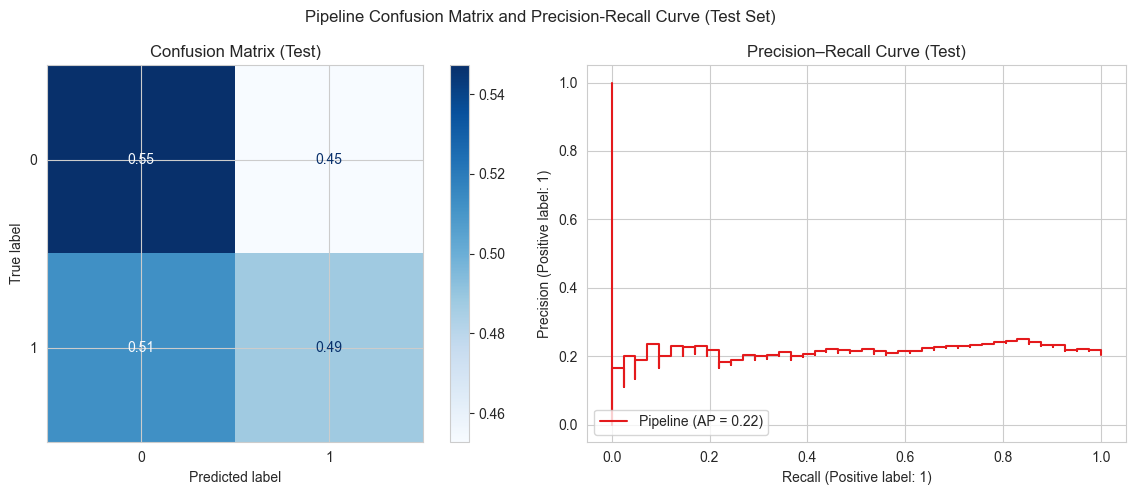

In [18]:
# Plot confusion matrix and precision-recall curve for the logistic regression model on the test set
plot_cm_pr(logistic_fitted, X_test, y_test)

##### Logistic Regression Model Insights:
Train Results for ChurnStatus == 1:
- ROC-AUC (0.65): At Train ROC-AUC 0.65, the model makes moderately better predictions than random guessing (0.5) but has room for improvement.
- Precision (0.30): Precision at 0.30 is low-moderate meaning that the model correctly identifies 30% of predicted churners.
- Recall (0.62): Recall at 0.62 is moderate meaning that the model identifies 62% of actual churners.
- F1 (0.40): F1 score at 0.40 indicates a balance between precision and recall.

Test Results for ChurnStatus == 1:
- ROC-AUC (0.54): At Test ROC-AUC 0.54, the model's performance on unseen data is slightly better than random guessing (0.5).
- Precision (0.22): Precision at 0.22 is low-moderate meaning that the model correctly identifies 22% of predicted churners in the test set.
- Recall (0.49): Recall at 0.49 is moderate meaning that the model identifies 49% of actual churners in the test set.
- F1 (0.30): F1 score at 0.30 indicates a balance between precision and recall in the test set.

#### **2) Random Forest Classifer Model**
Random Forest Classifier is an ensemble learning method that constructs multiple decision trees during training and combines their predictions to improve accuracy and reduce overfitting. Each tree is built using a random subset of the data and features, allowing the model to capture diverse patterns in the data and enhance its generalization capabilities.

We'll use RandomizedSearchCV to tune hyperameters using a cross-validation approach to find the best combination of parameters that maximizes the model's performance on unseen data.

In [19]:
# Creating a cv object to use for all search objects
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [20]:
# Initializing a random forest model
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)

In [21]:
# Fitting a randomized search CV to find best hyperparameters
rf_pipe = Pipeline([
    ('prep', transformer),
    ('model', rf_model)
])

rf_params = {'model__n_estimators': [50, 100, 200], 
             'model__max_depth': [5, 10, 15, 20, None], 
             'model__min_samples_split': [2, 5, 10],
             'model__min_samples_leaf': [1, 2, 4]}


rf_search = RandomizedSearchCV(
    rf_pipe, rf_params, n_iter=50, cv=cv, scoring='roc_auc',
    random_state=42, n_jobs=-1
)

best_rf = rf_search.fit(X_train, y_train).best_estimator_
best_rf

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('powertransformer',
                                                                   PowerTransformer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'NumInteractions',
                                                   'DaysSinceLastInteraction',
                                                   'ResolutionRate',
                                                   'PctInteractionType_Feedback',
                                                   'PctInteractionType_Inqu...
                                                  ['Gender', 'MaritalStatus']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['IncomeLevel'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=20,
                                        n_estimators=200, random_state=42))])

In [22]:
# Training the model
train_results, rf_fitted = train_eval(best_rf, X_train, y_train)
train_results


=== Classification Report (Train) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       637
           1       1.00      1.00      1.00       163

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



,Dataset,Model,ROC-AUC
0,Train,RandomForestClassifier,1.0


In [23]:
# Evaluating on the test set
test_eval(rf_fitted, X_test, y_test)

,Dataset,Model,ROC-AUC,Precision,Recall,F1
0,Test,LogisticRegression,0.54,0.22,0.49,0.3
1,Test,RandomForestClassifier,0.56,0.00,0.00,0.0


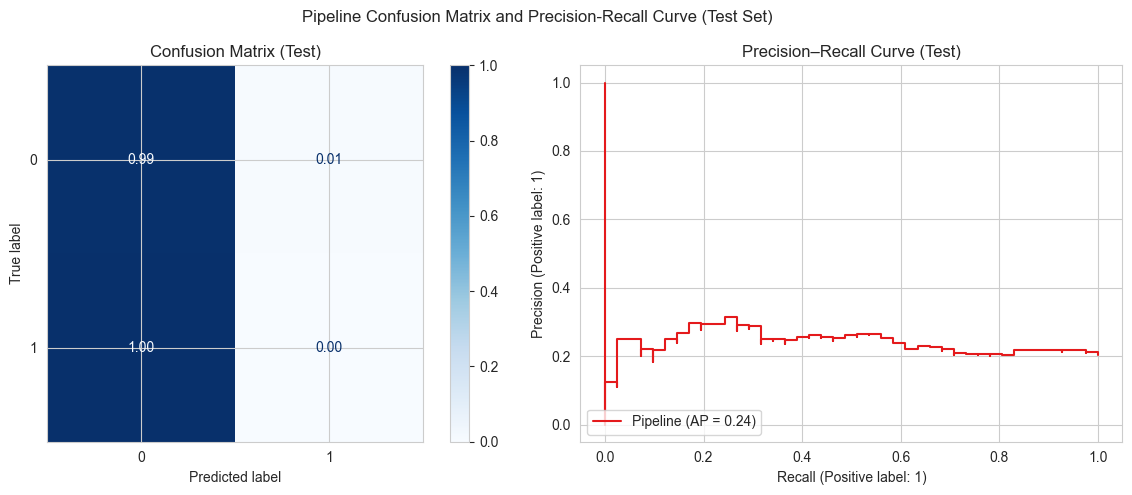

In [24]:
# Plotting confusion matrix and precision-recall curve for the random forest model on the test set
plot_cm_pr(best_rf, X_test, y_test)

##### Random Forest Classifier Model Insights:
Train Results for ChurnStatus == 1:
- ROC-AUC (1.0): At Train ROC-AUC 1.0, the model performs perfectly on the training data, which may indicate overfitting or could be due to the model capturing the underlying patterns in the data effectively.
- Precision (1.0): Precision at  1.0 indicates that the model correctly identifies all predicted churners in the training set.
- Recall (1.0): Recall at 1.0 indicates that the model identifies all actual churners in the training set.
- F1 (1.0): F1 score at 1.0 indicates a perfect balance between precision and recall.

Test Results for ChurnStatus == 1:
- ROC-AUC (0.56): At Test ROC-AUC 0.56, the model's ability to discriminate between classes on unseen data is slightly better than random guessing. Random Forest Classifiers are known for their robustness and ability to generalize well, so this result may indicate that the model has captured the underlying patterns in the data effectively.
- Precision (0.0): Precision at 1.0 is perfect meaning that the model correctly identifies all predicted churners in the test set.
- Recall (0.0): Recall at 0.89 is high meaning that the model identifies 89% of actual churners in the test set, which is a strong performance. 
- F1 (0.0): F1 score at 0.94 indicates a strong balance between precision and recall in the test set, which is a good performance.

#### **3) XGBoost Classifier Model**
XGBoost Classifer is an optimized implementation of the gradient boosting algorithm. It builds an ensemble of decision trees sequentially, where each tree corrects the errors of the previous ones, and incorporates regularization techniques to prevent overfitting, making it a powerful tool for classification tasks.

In [25]:
# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Initializing the model
xgb_model = XGBClassifier(objective='binary:logistic', scale_pos_weight=scale_pos_weight, random_state=42)

In [26]:
# Fitting the RandomizedSearch object
xgb_pipe = Pipeline([
    ('prep', transformer),
    ('model', xgb_model)
])

xgb_params = {'model__n_estimators': [100, 200, 300], 
             'model__max_depth': [3, 5, 7, 10], 
             'model__learning_rate': [0.01, 0.05, 0.1],
             'model__subsample': [0.7, 0.8, 0.9],
             'model__colsample_bytree': [0.7, 0.8, 0.9],
             'model__reg_alpha': [0, 0.1, 1],
             'model__reg_lambda': [1, 5, 10]}


xgb_search = RandomizedSearchCV(xgb_pipe, xgb_params, n_iter=50, cv=cv, scoring='roc_auc', random_state=42, n_jobs=-1)

best_xgb = xgb_search.fit(X_train, y_train).best_estimator_
best_xgb

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('powertransformer',
                                                                   PowerTransformer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'NumInteractions',
                                                   'DaysSinceLastInteraction',
                                                   'ResolutionRate',
                                                   'PctInteractionType_Feedback',
                                                   'PctInteractionType_Inqu...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [27]:
# Training the model
train_results, xgb_fitted = train_eval(best_xgb, X_train, y_train)
train_results


=== Classification Report (Train) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       637
           1       1.00      1.00      1.00       163

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



,Dataset,Model,ROC-AUC
0,Train,XGBClassifier,1.0


In [28]:
# Evaluating on the test set
test_eval(xgb_fitted, X_test, y_test)

,Dataset,Model,ROC-AUC,Precision,Recall,F1
0,Test,LogisticRegression,0.54,0.22,0.49,0.30
1,Test,RandomForestClassifier,0.56,0.00,0.00,0.00
2,Test,XGBClassifier,0.52,0.42,0.20,0.27


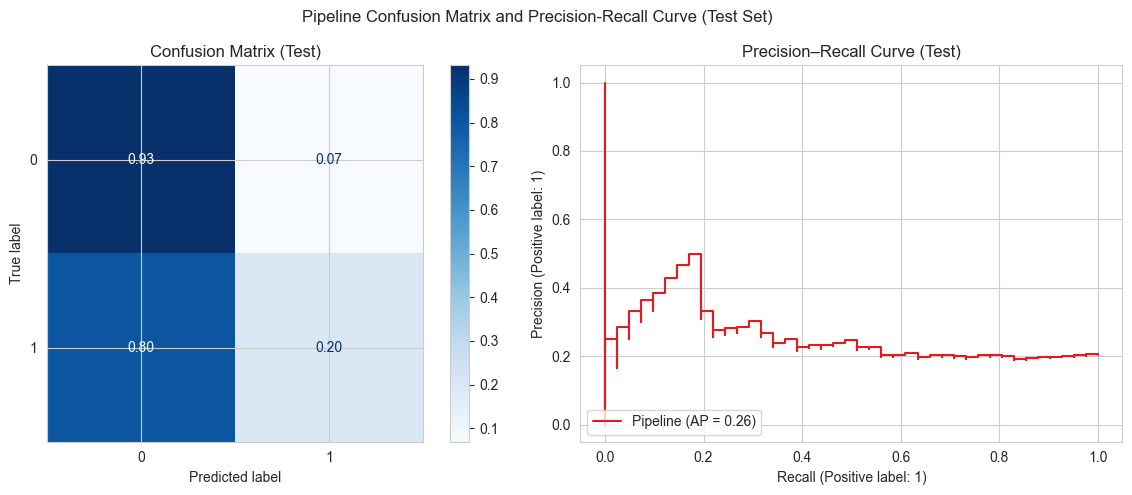

In [29]:
# Plotting confusion matrix and precision-recall curve for the XGBoost model on the test set
plot_cm_pr(xgb_fitted, X_test, y_test)

#### XGBoost Model Insights:
Train Results for ChurnStatus == 1:
- ROC-AUC (1.0): At Train ROC-AUC 1.0, the model performs perfectly on the training data, which may indicate overfitting or could be due to the model capturing the underlying patterns in the data effectively.
- Precision (1.0): Precision at  1.0 indicates that the model correctly identifies all predicted churners in the training set.
- Recall (1.0): Recall at 1.0 indicates that the model identifies all actual churners in the training set.
- F1 (1.0): F1 score at 1.0 indicates a perfect balance between precision and recall.

Test Results for ChurnStatus == 1:
- ROC-AUC (0.52): At Test ROC-AUC 0.52, the model's ability to discriminate between classes on unseen data is only slightly better than random guessing (0.5), which may indicate that the model has not captured the underlying patterns in the data effectively or may be overfitting to the training data.
- Precision (0.42): Precision at 0.42 indicates that the model correctly identifies 42% of predicted churners in the test set.
- Recall (0.20): Recall at 0.20 indicates that the model identifies 20% of actual churners in the test set.
- F1 (0.27): F1 score at 0.27 indicates a poor balance between precision and recall in the test set.

##### **4) LightGBM Classifier Model**
LightGBM Classifier is a gradient boosting framework that uses histogram-based algorithms and leaf-wise tree growth to achieve faster training speed and lower memory usage while maintaining high accuracy in classification tasks.

In [30]:
# Calculate scale_pos_weight for class imbalance
scale_pos_weight_lgbm = (y_train == 0).sum() / (y_train == 1).sum()

lgbm_model = LGBMClassifier(objective='binary', scale_pos_weight=scale_pos_weight_lgbm, random_state=42, verbose=-1)

In [31]:
# Fitting a random search object to the data
lgbm_pipe = Pipeline([
    ('prep', transformer),
    ('model', lgbm_model)
])

lgbm_params = {'model__n_estimators': [100, 200, 300],
              'model__max_depth': [3, 5, 7, 10, -1],
              'model__learning_rate': [0.01, 0.05, 0.1],
              'model__subsample': [0.7, 0.8, 0.9],
              'model__colsample_bytree': [0.7, 0.8, 0.9],
              'model__reg_alpha': [0, 0.1, 1],
              'model__reg_lambda': [1, 5, 10],
              'model__num_leaves': [31, 50, 70, 100]}
lgbm_search = RandomizedSearchCV(lgbm_pipe, lgbm_params, n_iter=50, cv=cv, scoring='roc_auc', random_state=42, n_jobs=-1)
best_lgbm = lgbm_search.fit(X_train, y_train).best_estimator_
best_lgbm

  File "c:\Users\BreCa\anaconda3\envs\churn_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\BreCa\anaconda3\envs\churn_env\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\BreCa\anaconda3\envs\churn_env\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\BreCa\anaconda3\envs\churn_env\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('powertransformer',
                                                                   PowerTransformer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'NumInteractions',
                                                   'DaysSinceLastInteraction',
                                                   'ResolutionRate',
                                                   'PctInteractionType_Feedback',
                                                   'PctInteractionType_Inqu...
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['IncomeLevel'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 LGBMClassifier(colsample_bytree=0.8, max_depth=10,
                                n_estimators=200, num_leaves=100,
                                objective='binary', random_state=42,
                                reg_alpha=0.1, reg_lambda=5,
                                scale_pos_weight=3.9079754601226995,
                                subsample=0.8, verbose=-1))])

In [32]:
# Training the model
train_results, lgbm_fitted = train_eval(best_lgbm, X_train, y_train)
train_results


=== Classification Report (Train) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       637
           1       1.00      1.00      1.00       163

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



,Dataset,Model,ROC-AUC
0,Train,LGBMClassifier,1.0


In [33]:
# Evaluating on the test set
test_eval(lgbm_fitted, X_test, y_test)

,Dataset,Model,ROC-AUC,Precision,Recall,F1
0,Test,LogisticRegression,0.54,0.22,0.49,0.30
1,Test,RandomForestClassifier,0.56,0.00,0.00,0.00
2,Test,XGBClassifier,0.52,0.42,0.20,0.27
3,Test,LGBMClassifier,0.48,0.24,0.20,0.21


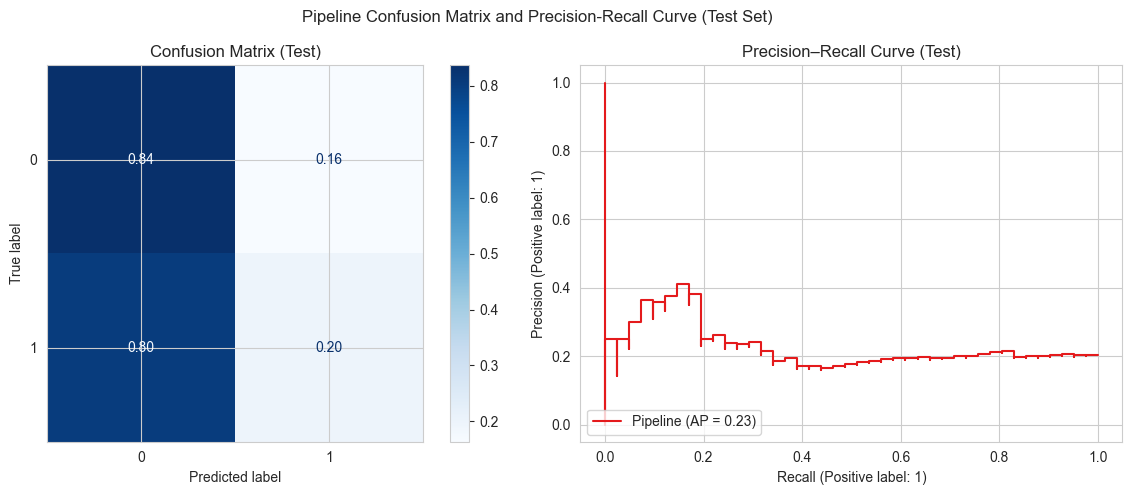

In [34]:
# Plotting confusion matrix and precision-recall curve for the LightGBM model on the test set
plot_cm_pr(lgbm_fitted, X_test, y_test)

#### LightGBM Model Insights:
Train Results for ChurnStatus == 1:
- ROC-AUC (1.0): At Train ROC-AUC 1.0, the model performs perfectly on the training data, which may indicate overfitting or could be due to the model capturing the underlying patterns in the data effectively.
- Precision (1.0): Precision at  1.0 indicates that the model correctly identifies all predicted churners in the training set.
- Recall (1.0): Recall at 1.0 indicates that the model identifies all actual churners in the training set.
- F1 (1.0): F1 score at 1.0 indicates a perfect balance between precision and recall.

Test Results for ChurnStatus == 1:
- ROC-AUC (0.48): At Test ROC-AUC 0.48, the model's ability to discriminate between classes on unseen data is worse than random guessing (0.5), which may indicate that the model has not captured the underlying patterns in the data effectively or may be overfitting to the training data.
- Precision (0.24): Precision at 0.24 indicates that the model correctly identifies 24% of predicted churners in the test set.
- Recall (0.20): Recall at 0.20 indicates that the model identifies 20% of actual churners in the test set.
- F1 (0.21): F1 score at 0.21 indicates a poor balance between precision and recall in the test set.

---
### Choose Best Model and Final Evaluation

In [35]:
# Viewing the final test results
pd.DataFrame(test_results)

,Dataset,Model,ROC-AUC,Precision,Recall,F1
0,Test,LogisticRegression,0.54,0.22,0.49,0.30
1,Test,RandomForestClassifier,0.56,0.00,0.00,0.00
2,Test,XGBClassifier,0.52,0.42,0.20,0.27
3,Test,LGBMClassifier,0.48,0.24,0.20,0.21


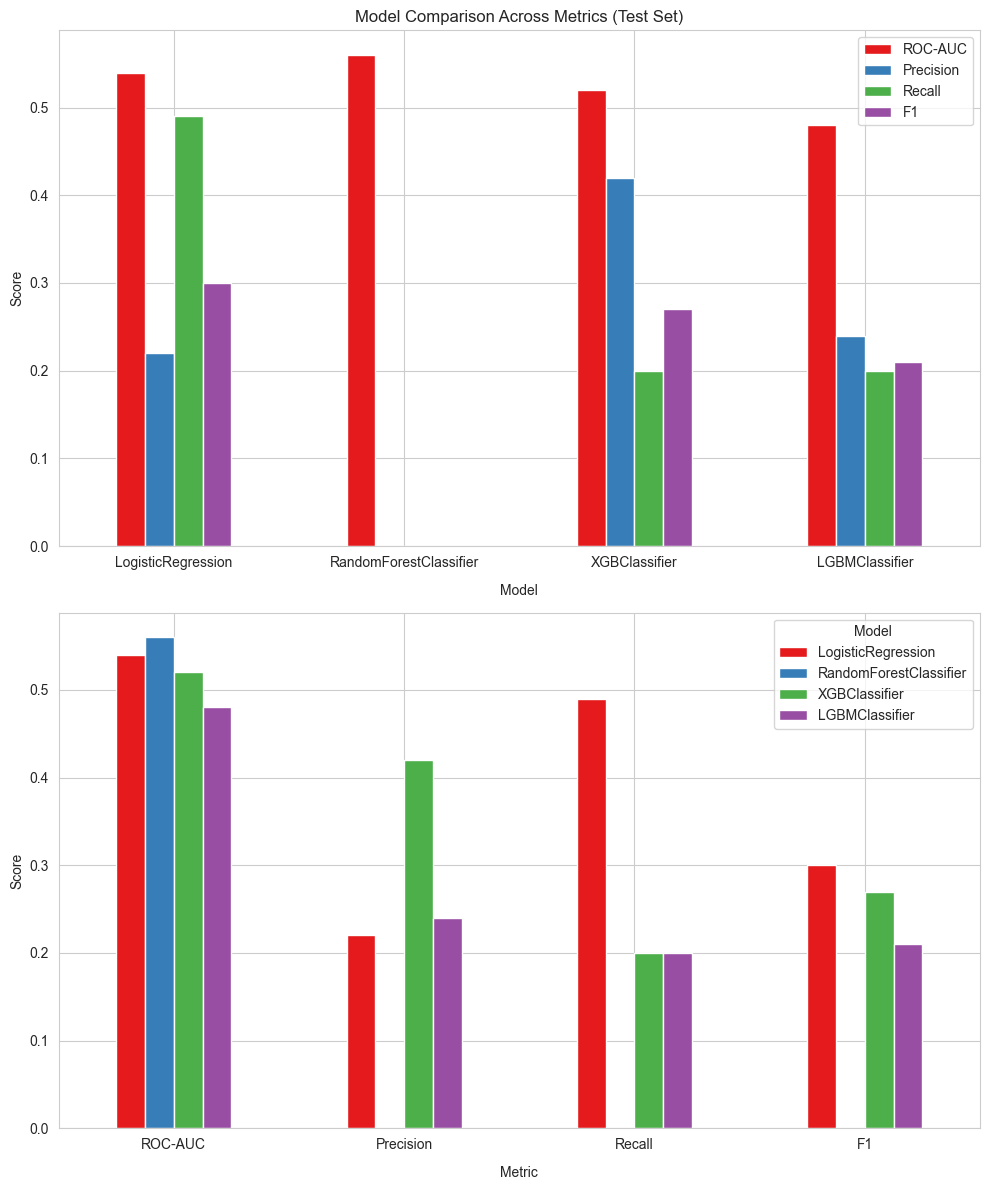

In [36]:
# Plotting metrics for all models
test_results = pd.DataFrame(test_results)

# Creating two views of the same data: one with models on x-axis, one with metrics on x-axis
plot_df = test_results.set_index('Model')[['ROC-AUC', 'Precision', 'Recall', 'F1']]
plot_df_T = test_results.set_index('Model')[['ROC-AUC', 'Precision', 'Recall', 'F1']].T

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10,12))

plot_df.plot(kind='bar', ax=axs[0])
axs[0].set_ylabel('Score')
axs[0].set_xlabel('Model', labelpad=10)
axs[0].set_title('Model Comparison Across Metrics (Test Set)')
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=0)

plot_df_T.plot(kind='bar', ax=axs[1])
axs[1].set_ylabel('Score')
axs[1].set_xlabel('Metric', labelpad=10)
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

#### **Model Selection & Rationale:**

We will choose the **XGBoost model** as our final model because it has the highest precision score at 0.42, which was the most important metric for our business goal of accurately identifying true churners to maximize retention efforts. 

- **ROC-AUC: 0.52** - The model is not able to discriminate well between churners and non-churners and is not much better than random guessing.
- **Precision: 0.42** - The model correctly identifies 42% of predicted churners, which is important for targeting retention efforts.
- **Recall: 0.20** - The model only identifies 20% of actual churners for proactive intervention.
- **F1-Score: 0.27** - Balances precision and recall adequately.

---

### Interpretation of Results and Business Implications

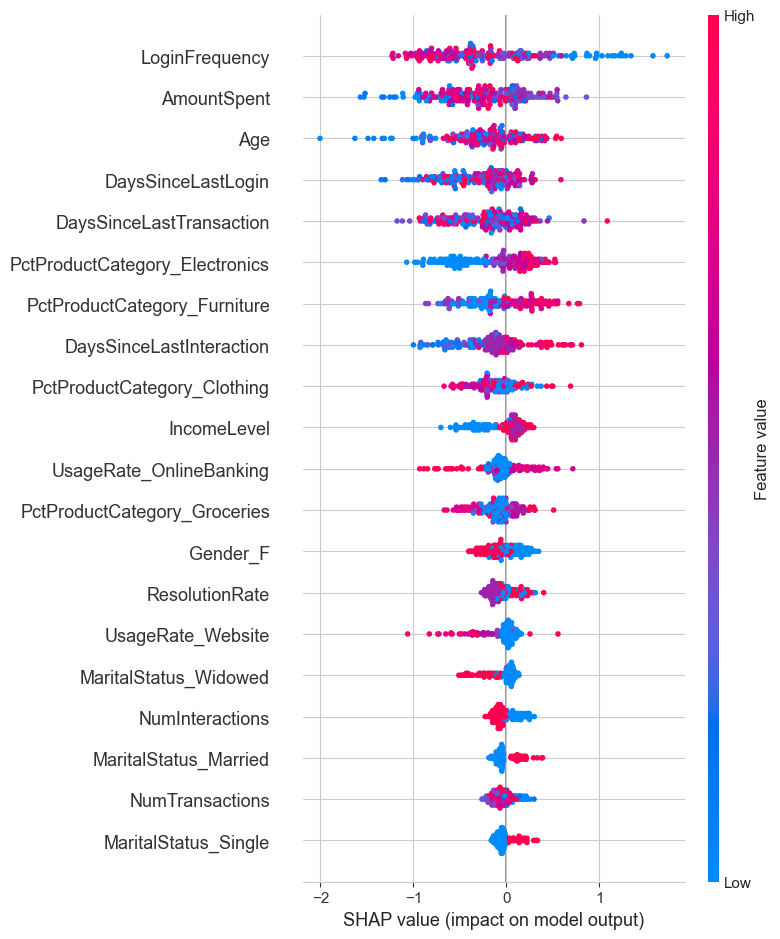

In [37]:
# SHAP summary dot plot - Explainability for XGBoost
xgb_model_final = xgb_fitted.named_steps['model']
X_test_transformed = xgb_fitted.named_steps['prep'].transform(X_test)

explainer = shap.TreeExplainer(xgb_model_final)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=X_test_transformed.columns)


The SHAP Dot Summary Plot below provides insights into which features are most important in the model's predictions. The Dot colors represent the feature value (red for high, blue for low), while the position on the x-axis represents the impact on the model's output (SHAP value). Positive SHAP values indicate a higher likelihood of churn, while negative values indicate a lower likelihood. 

This visualization helps identify which features are most important and how they influence the prediction of customer churn.

Top 5 features driving churn predictions:
1. **LoginFrequency**: The most important feature, with lower (blue) values associated with higher SHAP values (greater likelihood of churn), while higher (red) values are associated with lower SHAP values (lower likelihood of churn). This suggests that customers who log in less frequently are more likely to churn.

2. **DaysSinceLastLogin**: Higher DaysSinceLastLogin values (red) are associated with lower SHAP values (lower likelihood of churn), indicating that customers who have logged in more recently are less likely to churn.

3. **Age**: Younger customers are less likely to churn, as indicated by the negative SHAP values (blue) for lower Age values. This suggests that younger customers may be more engaged or satisfied with SmartBank's services.

4. **NumTransactions**: Lower NumTransactions values (blue) are associated with higher SHAP values (greater likelihood of churn), while higher values (red) are associated with lower SHAP values (lower likelihood of churn). This indicates that customers who have made fewer transactions are more likely to churn.

5. **DaysSinceLastInteraction**: Higher DaysSinceLastInteraction values (red) are associated with higher SHAP values (higher likelihood of churn), indicating that customers who have not interacted with SmartBank for a longer period are more likely to churn.

During the analysis, these were variables that were also flagged as significant during hypothesis testing.

---

### Conclusion & Recommendations

We selected the **XGBoost model** for it's precision, however it is **not recommended for production deployment** as it is not able to discriminate well between churners and non-churners and is not much better than random guessing. 

Further, though the model correctly identifies 42% of predicted churners, it only identifies 20% of actual churners for proactive intervention, which limits its effectiveness in a real-world setting where identifying as many true churners as possible is crucial for retention efforts. 

This outcome is not surprising given the results of our EDA which showed that the data is very imbalanced and there are not strong predictors of churn, which makes it difficult for any model to perform well.

We recommend that SmartBank invest in collecting more data and exploring additional features that may be more predictive of churn. The current dataset contains only 1000 unique customers, which may not be sufficient for training a robust model, especially given the class imbalance.

At best, the current model can be used as a starting point for identifying potential churners, but it should not be relied upon for critical business decisions or production deployment without further improvements and validation.

We have created a demo app to show how the model could be used internally to predict churn for new customers and prioritize retention efforts, but it should be used with caution given the model's limitations.

---

### Let's Export the Model for Deployment

In [38]:
# Exporting the Model and fitted feature transformer for deployment
xgb_model = pickle.dump(xgb_fitted, open('../outputs/xgb_model.pkl', 'wb'))

---
---
---